In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path=r"C:\Users\learn\Documents\NareshIT\EDA\Pandas\Visadataset - Visadataset.csv"
visa_df = pd.read_csv(file_path)
visa_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [3]:
continent_keys=visa_df['continent'].value_counts().keys()
continent_values=visa_df['continent'].value_counts().values

cat=visa_df.select_dtypes(include='object').columns
num=visa_df.select_dtypes(exclude='object').columns

In [4]:
caseStatus_keys=visa_df['case_status'].value_counts().keys()
caseStatus_values=visa_df['case_status'].value_counts().values

In [5]:
caseStatus_keys,caseStatus_values

(Index(['Certified', 'Denied'], dtype='object', name='case_status'),
 array([17018,  8462], dtype=int64))

- There are total 25480 applicants are there

- In that 25480 applicants 17018 applicants got the Visa

- 8462 Applicants did not get the visa

- also there are 16861 applicants are applied for Visa from Asia

- We want to know how many applications from asia got certified

- and how many applicants from asia got denied 

In [16]:
# Step1: Select data continent Data
# Step2: continent data == 'Asia' it is con1
# Step3; select the case status data 
# Step4: case status data == 'certified' is con2
# Step5: con=con1&con2
# Step6: apply main df on get the len



con1 = visa_df['continent'] == 'Asia'
con2 = visa_df['case_status'] == 'Certified'
con=con1&con2
len(visa_df[con])

11012

In [21]:
labels=visa_df['continent'].unique()

for i in labels:
    con1 = visa_df['continent'] == i
    con2 = visa_df['case_status'] == 'Certified'
    con=con1&con2
    print(len(visa_df[con]))


11012
397
2037
2957
493
122


In [22]:
visa_df['continent'].unique()

array(['Asia', 'Africa', 'North America', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [25]:
visa_df['continent'].value_counts().keys().unique()

Index(['Asia', 'Europe', 'North America', 'South America', 'Africa',
       'Oceania'],
      dtype='object', name='continent')

In [37]:
labels=visa_df['continent'].unique()
certified_count = []
denied_count = []
for i in labels:
    con1 = visa_df['continent'] == i
    con2 = visa_df['case_status'] == 'Certified'
    con3 = visa_df['case_status'] == 'Denied'
    cer_con = con1&con2
    certified_count.append(len(visa_df[cer_con]))
    den_con = con1&con3
    denied_count.append(len(visa_df[den_con]))
    
cols=sorted(visa_df['case_status'].unique())
pd.DataFrame(zip(certified_count,denied_count),columns=cols,index=labels)

,Certified,Denied
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


**Cross Tab**

In [40]:
# pd.crosstab(<index>,<columns>)

col1=visa_df['continent']
col2=visa_df['case_status']
pd.crosstab(col1,col2)

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [42]:
col1=visa_df['continent']
col2=visa_df['case_status']
pd.crosstab(col2,col1)

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


In [43]:
col1=visa_df['continent']
col2=visa_df['case_status']
r1=pd.crosstab(col1,col2)

<Axes: xlabel='continent'>

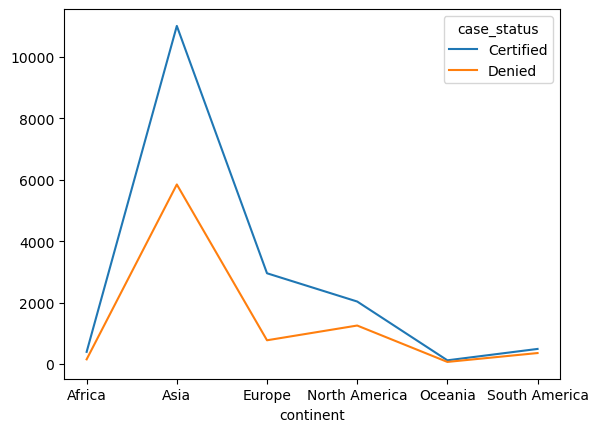

In [48]:
r1.plot()

<Axes: xlabel='continent'>

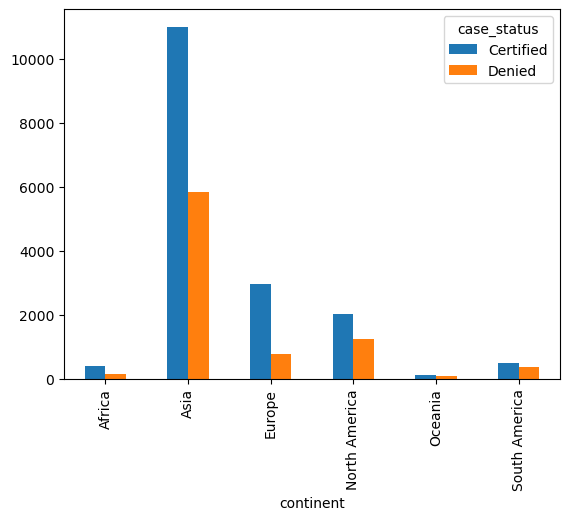

In [46]:
r1.plot(kind='bar')

**Case_Status-continent-education_of_employee**

In [47]:
# from asia there 16k application applied for visa
#     in that 11k ppl got certified
#            in that 11k ppl diffrent education application are available

# We want those informatin

In [50]:
# pd.crosstab(<index>,<columns>)
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col1,col2]
pd.crosstab(col3,cols)

continent                Africa             Asia           Europe         \
case_status           Certified Denied Certified Denied Certified Denied   
education_of_employee                                                      
Bachelor's                   81     62      4407   2761      1040    259   
Doctorate                    43     11       780    143       788     58   
High School                  23     43       676   1614       162    328   
Master's                    250     38      5149   1331       967    130   

continent             North America          Oceania        South America  \
case_status               Certified Denied Certified Denied     Certified   
education_of_employee                                                       
Bachelor's                      641    584        38     28           160   
Doctorate                       207     51        19      3            75   
High School                     210    191        19     17            74   
Master's                        979    429        46     22           184   

continent                     
case_status           Denied  
education_of_employee         
Bachelor's               173  
Doctorate                 14  
High School               63  
Master's                 109

In [52]:
# pd.crosstab(<index>,<columns>)
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col1,col2]
pd.crosstab(cols,col3)

education_of_employee      Bachelor's  Doctorate  High School  Master's
continent     case_status                                              
Africa        Certified            81         43           23       250
              Denied               62         11           43        38
Asia          Certified          4407        780          676      5149
              Denied             2761        143         1614      1331
Europe        Certified          1040        788          162       967
              Denied              259         58          328       130
North America Certified           641        207          210       979
              Denied              584         51          191       429
Oceania       Certified            38         19           19        46
              Denied               28          3           17        22
South America Certified           160         75           74       184
              Denied              173         14           63       109

In [53]:
# pd.crosstab(<index>,<columns>)
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
pd.crosstab(col1,cols)

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109

In [54]:
# pd.crosstab(<index>,<columns>)
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
pd.crosstab(cols,col1)

continent                          Africa  Asia  Europe  North America  \
case_status education_of_employee                                        
Certified   Bachelor's                 81  4407    1040            641   
            Doctorate                  43   780     788            207   
            High School                23   676     162            210   
            Master's                  250  5149     967            979   
Denied      Bachelor's                 62  2761     259            584   
            Doctorate                  11   143      58             51   
            High School                43  1614     328            191   
            Master's                   38  1331     130            429   

continent                          Oceania  South America  
case_status education_of_employee                          
Certified   Bachelor's                  38            160  
            Doctorate                   19             75  
            High School                 19             74  
            Master's                    46            184  
Denied      Bachelor's                  28            173  
            Doctorate                    3             14  
            High School                 17             63  
            Master's                    22            109

In [55]:
# pd.crosstab(<index>,<columns>)
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col1,col3]
pd.crosstab(col2,cols)

continent                 Africa                                      Asia  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
case_status                                                                  
Certified                     81        43          23      250       4407   
Denied                        62        11          43       38       2761   

continent                                                Europe            \
education_of_employee Doctorate High School Master's Bachelor's Doctorate   
case_status                                                                 
Certified                   780         676     5149       1040       788   
Denied                      143        1614     1331        259        58   

continent              ... North America             Oceania            \
education_of_employee  ...   High School Master's Bachelor's Doctorate   
case_status            ...                                               
Certified              ...           210      979         38        19   
Denied                 ...           191      429         28         3   

continent                                  South America            \
education_of_employee High School Master's    Bachelor's Doctorate   
case_status                                                          
Certified                      19       46           160        75   
Denied                         17       22           173        14   

continent                                   
education_of_employee High School Master's  
case_status                                 
Certified                      74      184  
Denied                         63      109  

[2 rows x 24 columns]

In [56]:
# pd.crosstab(<index>,<columns>)
col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col1,col3]
pd.crosstab(cols,col2)

case_status                          Certified  Denied
continent     education_of_employee                   
Africa        Bachelor's                    81      62
              Doctorate                     43      11
              High School                   23      43
              Master's                     250      38
Asia          Bachelor's                  4407    2761
              Doctorate                    780     143
              High School                  676    1614
              Master's                    5149    1331
Europe        Bachelor's                  1040     259
              Doctorate                    788      58
              High School                  162     328
              Master's                     967     130
North America Bachelor's                   641     584
              Doctorate                    207      51
              High School                  210     191
              Master's                     979     429
Oceania       Bachelor's                    38      28
              Doctorate                     19       3
              High School                   19      17
              Master's                      46      22
South America Bachelor's                   160     173
              Doctorate                     75      14
              High School                   74      63
              Master's                     184     109

<Axes: xlabel='continent'>

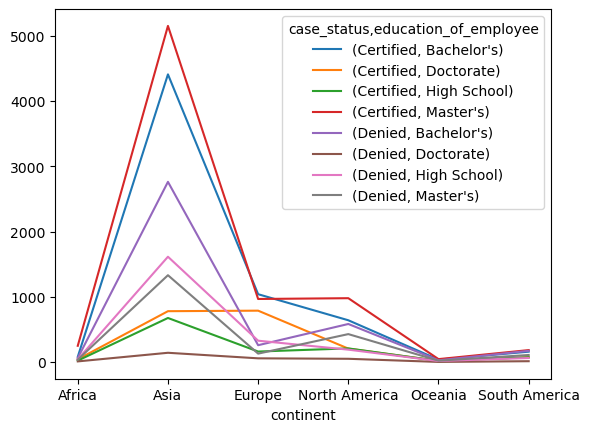

In [62]:
# pd.crosstab(<index>,<columns>)

col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2 = pd.crosstab(col1,cols)
r2.plot()

<Axes: ylabel='Density'>

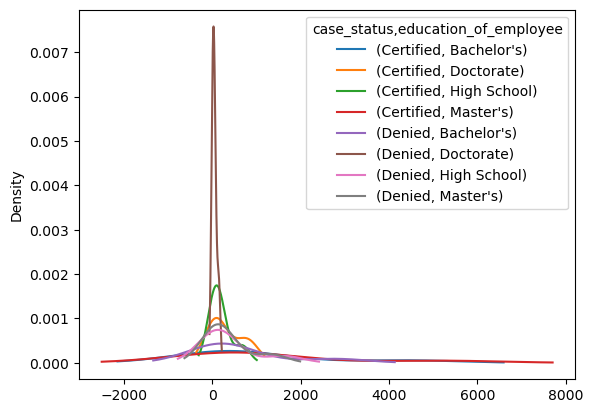

In [63]:
# pd.crosstab(<index>,<columns>)

col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2 = pd.crosstab(col1,cols)
r2.plot(kind='kde')

<Axes: ylabel='Density'>

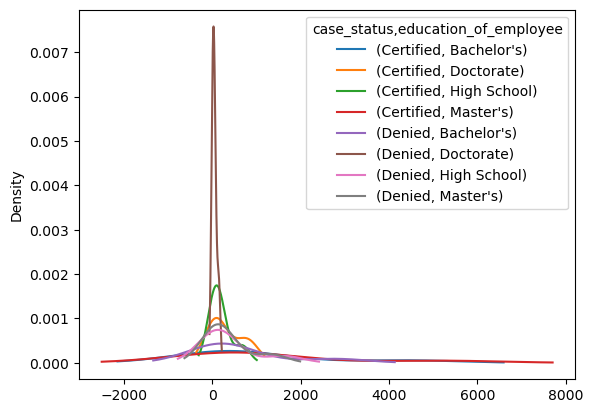

In [66]:
# pd.crosstab(<index>,<columns>)

col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2 = pd.crosstab(col1,cols)
r2.plot(kind='density')

<Axes: xlabel='continent'>

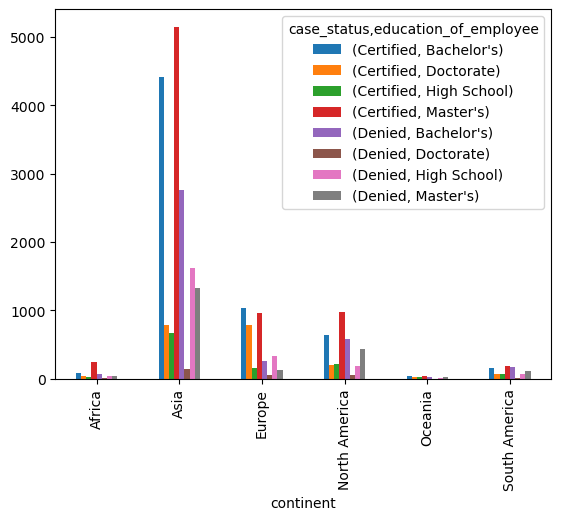

In [64]:
# pd.crosstab(<index>,<columns>)

col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2 = pd.crosstab(col1,cols)
r2.plot(kind='bar')

<Axes: ylabel='continent'>

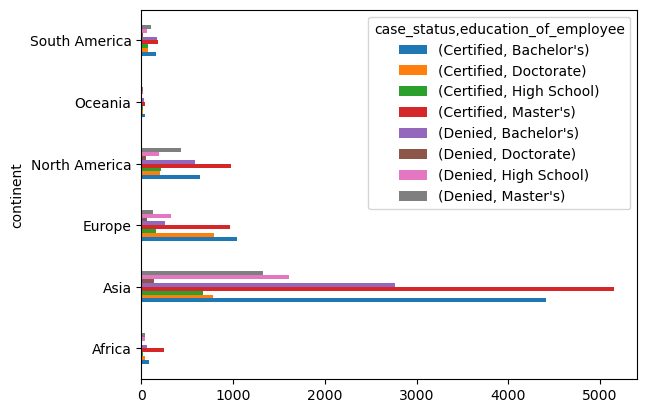

In [65]:
# pd.crosstab(<index>,<columns>)

col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2 = pd.crosstab(col1,cols)
r2.plot(kind='barh')

<Axes: xlabel='continent'>

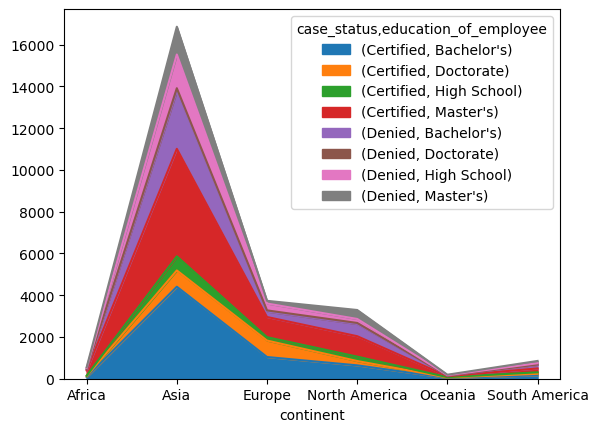

In [67]:
# pd.crosstab(<index>,<columns>)

col1=visa_df['continent']
col2=visa_df['case_status']
col3=visa_df['education_of_employee']
cols=[col2,col3]
r2 = pd.crosstab(col1,cols)
r2.plot(kind='area')

**group by**

In [70]:
visa_df['education_of_employee'].value_counts()

education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

In [72]:
visa_df['prevailing_wage']
# Wages are numerical values
# 25480 applicants are available
# different applicants having the diffrent wages

In [73]:
visa_df.groupby('education_of_employee')

In [74]:
list(visa_df.groupby('education_of_employee'))

[("Bachelor's",
           case_id      continent education_of_employee has_job_experience  \
  2         EZYV03           Asia            Bachelor's                  N   
  3         EZYV04           Asia            Bachelor's                  N   
  6         EZYV07           Asia            Bachelor's                  N   
  7         EZYV08  North America            Bachelor's                  Y   
  8         EZYV09           Asia            Bachelor's                  N   
  ...          ...            ...                   ...                ...   
  25466  EZYV25467         Europe            Bachelor's                  Y   
  25468  EZYV25469           Asia            Bachelor's                  N   
  25473  EZYV25474           Asia            Bachelor's                  Y   
  25475  EZYV25476           Asia            Bachelor's                  Y   
  25479  EZYV25480           Asia            Bachelor's                  Y   
  
        requires_job_training  no_of_employee

In [75]:
visa_df.groupby('education_of_employee').count()

,case_id,continent,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
education_of_employee,,,,,,,,,,,
Bachelor's,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234,10234
Doctorate,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192,2192
High School,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420
Master's,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634,9634


In [76]:
visa_df.groupby('education_of_employee').size()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
dtype: int64

In [80]:
# based on group by select an another column
visa_df.groupby('education_of_employee')['prevailing_wage']

In [78]:
visa_df.groupby('education_of_employee')['prevailing_wage'].count()

education_of_employee
Bachelor's     10234
Doctorate       2192
High School     3420
Master's        9634
Name: prevailing_wage, dtype: int64

In [81]:
visa_df['prevailing_wage'].mean()
# mean wage of all 24580 observation
# Bacheolrs,Doctors,hs,master

74455.81459209183

In [87]:
visa_df[visa_df['education_of_employee'] == "Bachelor's"]['prevailing_wage'].mean()

73405.44373547

In [84]:
visa_df.groupby('education_of_employee')['prevailing_wage'].mean()

education_of_employee
Bachelor's     73405.443735
Doctorate      64561.076657
High School    71582.147756
Master's       78843.057843
Name: prevailing_wage, dtype: float64

In [86]:
con=visa_df['case_status'] == 'Certified' 
new_df = visa_df[con]
new_df.groupby('continent').size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [88]:
# I want to know min wage of the Asis ppl
visa_df['prevailing_wage'].min()
con=visa_df['continent'] == 'Asia'
new_df=visa_df[con]
new_df['prevailing_wage'].min()

3.3188

In [91]:
visa_df[visa_df['continent'] == "Asia"]['prevailing_wage'].min()

3.3188

In [89]:
visa_df.groupby('continent')['prevailing_wage'].min()

continent
Africa           32.9286
Asia              3.3188
Europe            9.1753
North America     2.1367
Oceania          24.4888
South America     3.0031
Name: prevailing_wage, dtype: float64

- We have seen **continent and case status**
- we have seen three **continent, case status and Edution of employee**
- we also done similar analysis using group by
- only categorical column analysis completed
- only numerical column analysis completed
- Also BI variate and multivariate analysis also completed
- Now we need to perform two nuumerical column analysis
    - this will give relation between two columns which are numerical in nature
    - so we can perform **correlation matrix** to get the relationship
    - also need to perform **scatter plots** to visualize the relation

**plt.scatter**

In [6]:
x=range(0,11)
y=range(0,11)
x,y

(range(0, 11), range(0, 11))

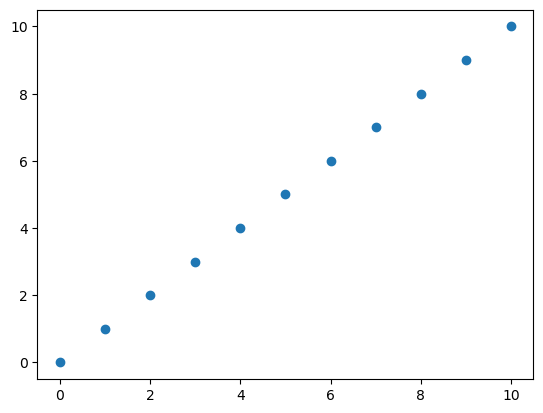

In [7]:
plt.scatter(x,y)

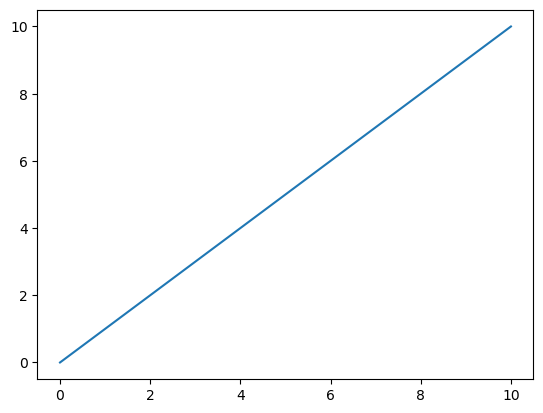

In [8]:
plt.plot(x,y)

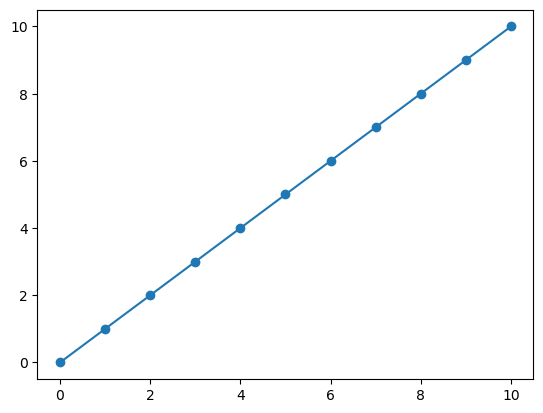

In [9]:
x=range(0,11)
y=range(0,11)
plt.scatter(x,y)
plt.plot(x,y)

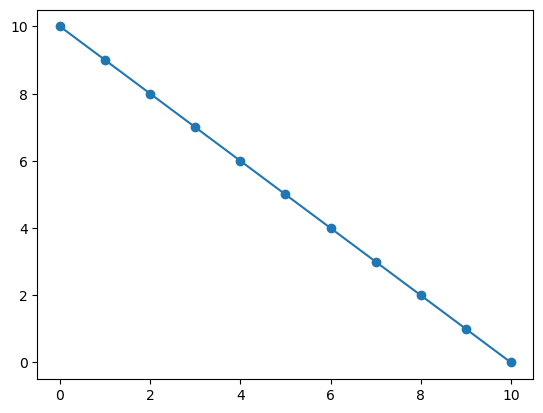

In [11]:
x=range(0,11) # o to 10
y=range(10,-1,-1) # 10 to -1+1=0
plt.scatter(x,y)
plt.plot(x,y)

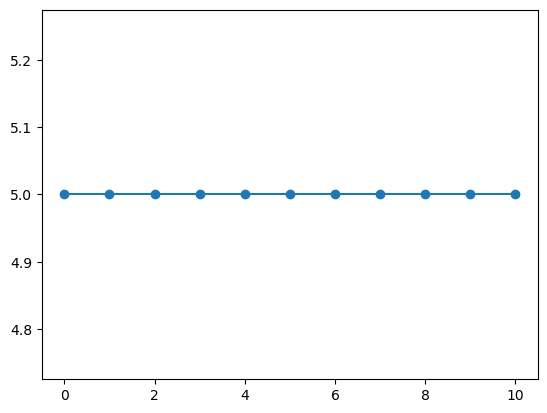

In [13]:
x=range(0,11) # o to 10
y= [5 for i in range(0,11)]
plt.scatter(x,y)
plt.plot(x,y)

In [14]:
[5 for i in range(0,11)]

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

In [15]:
cat

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [16]:
num

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [20]:
visa_df.corr()

ValueError: could not convert string to float: 'EZYV01'

In [19]:
visa_df.corr(numeric_only=True)

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


In [21]:
# col1 = no of employee read
# col2 = yr of estab
# col3 = prevailing_wage	
# plt.subplot(1,3,1).scatter(col1,col3)

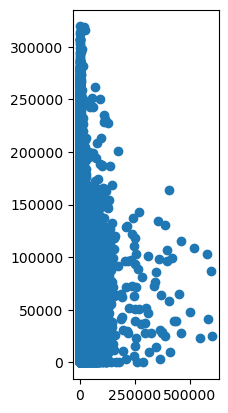

In [23]:
col1 = visa_df['no_of_employees']
col2 = visa_df['yr_of_estab']
col3 = visa_df['prevailing_wage']
plt.subplot(1,3,1).scatter(col1,col3)

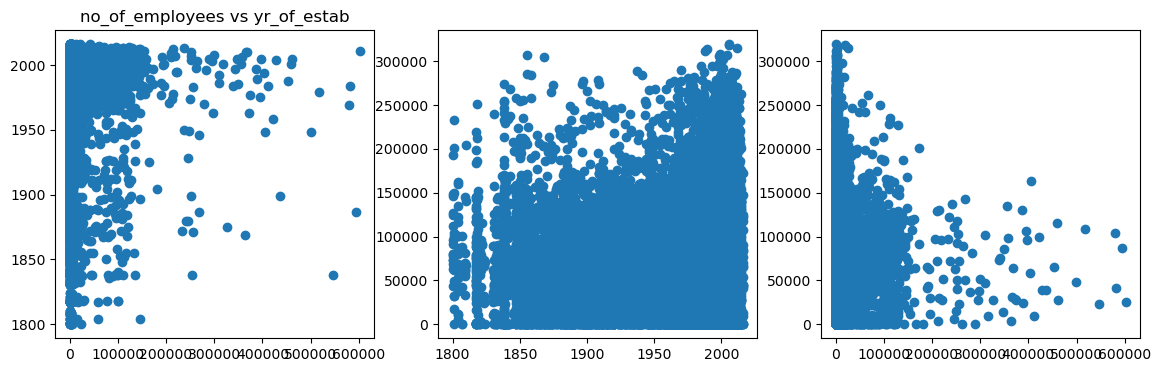

In [34]:
col1 = visa_df['no_of_employees']
col2 = visa_df['yr_of_estab']
col3 = visa_df['prevailing_wage']
plt.figure(figsize=(14,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.title('no_of_employees vs yr_of_estab')
plt.subplot(1,3,2).scatter(col2,col3)
plt.subplot(1,3,3).scatter(col1,col3)
plt.show()

In [39]:
# Winequality dataset
# Load the dataset
# perform the correlation

In [35]:
file_path=r"C:\Users\learn\Documents\NareshIT\EDA\Pandas\winequality_red.csv"
wine_df = pd.read_csv(file_path)
wine_df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [36]:
wine_cat=visa_df.select_dtypes(include='object').columns
wine_num=visa_df.select_dtypes(exclude='object').columns

In [37]:
len(wine_cat),len(wine_num)

(9, 3)

In [40]:
wine_df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [41]:
wine_df.corr(numeric_only=True)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


In [43]:
visa_corr=visa_df.corr(numeric_only=True)
visa_corr

,no_of_employees,yr_of_estab,prevailing_wage
no_of_employees,1.000000,-0.017770,-0.009523
yr_of_estab,-0.017770,1.000000,0.012342
prevailing_wage,-0.009523,0.012342,1.000000


**Heat map**
- Any matrix values we can visualize using a heat map
- Heat map will provide colors for different values
- Heap map also provides colors bar which indicates, the color and its value
- For example the values ranges form 0.8 to 1 display as **blue color**
- so we need to check values, we can directly see  the blue color
- so immediately we can sense blue color means highest values which is 0.8 to 1
- heat map available in **sea born**

<Axes: >

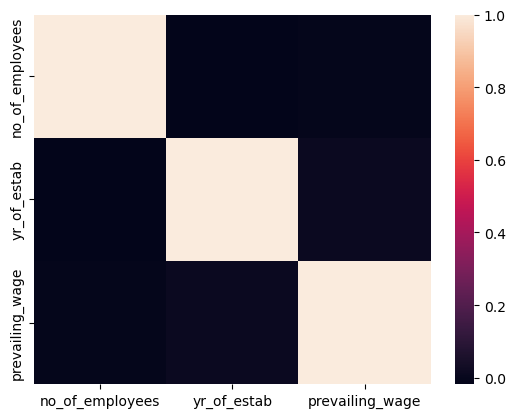

In [44]:
visa_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr)

<Axes: >

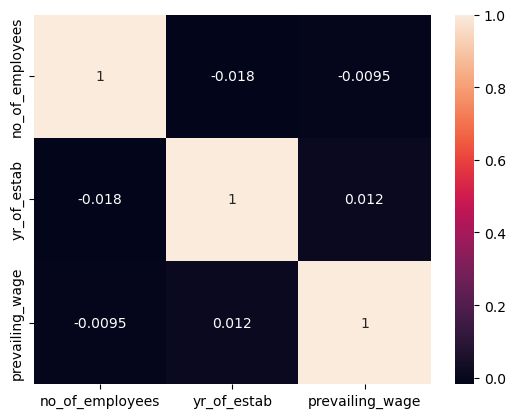

In [45]:
visa_corr=visa_df.corr(numeric_only=True)
sns.heatmap(visa_corr,annot=True)

<Axes: >

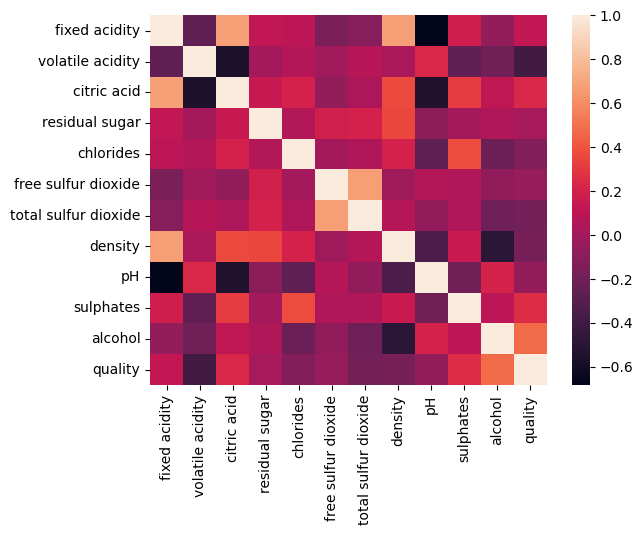

In [48]:
wine_data_corr=wine_df.corr(numeric_only=True)
sns.heatmap(wine_data_corr)

<Axes: >

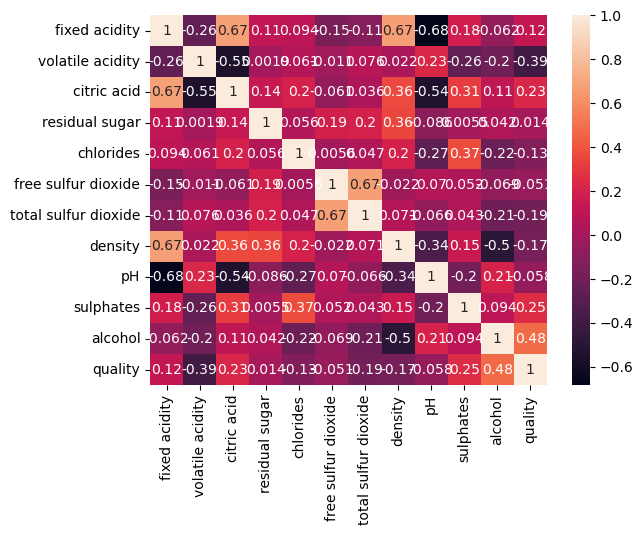

In [46]:
wine_data_corr=wine_df.corr(numeric_only=True)
sns.heatmap(wine_data_corr,annot=True)

<Axes: >

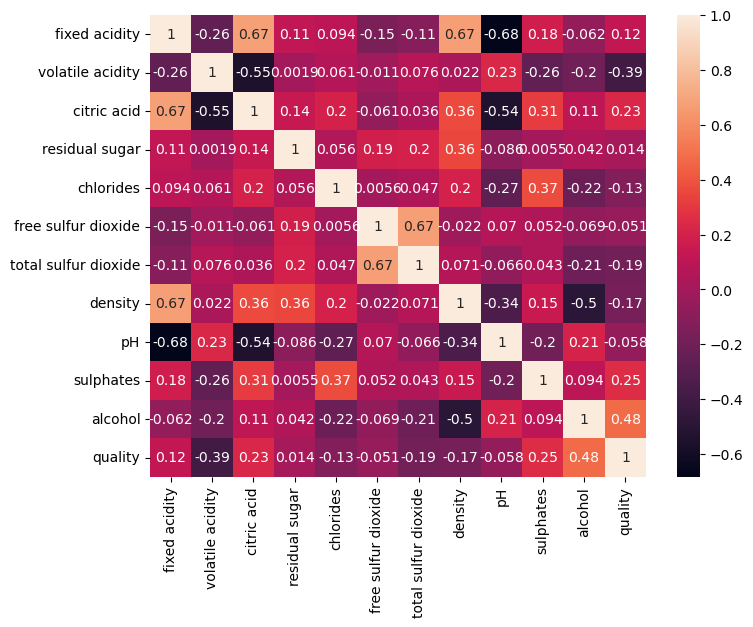

In [50]:
wine_data_corr=wine_df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(wine_data_corr,annot=True)

In [51]:
wine_df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

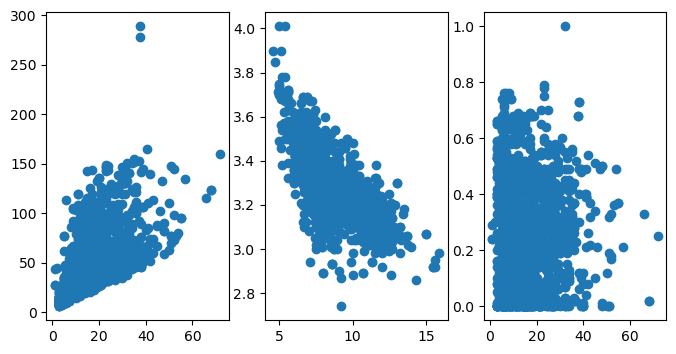

In [54]:
col1 = wine_df['free sulfur dioxide']
col2 = wine_df['total sulfur dioxide']
col3 = wine_df['fixed acidity']
col4 = wine_df['pH']
col5 = wine_df['citric acid']
plt.figure(figsize=(8,4))
plt.subplot(1,3,1).scatter(col1,col2)
plt.subplot(1,3,2).scatter(col3,col4)
plt.subplot(1,3,3).scatter(col1,col5)